In [12]:
import math
from typing import Set, Tuple, NamedTuple
from graphviz import Digraph
import torch

In [13]:
class Params:
    def __init__(self, data: float, _children=(), op='', label=''):
        self.data = data
        self._children: Set['Params'] = set(_children)
        self.op = op
        self.label = label
        self.grad: float = 0.0

    def __repr__(self):
        return f"Params(data={self.data:.4f}, label='{self.label}', op='{self.op}', grad={self.grad:.4f})"

    # ----- Basic arithmetic -----
    def __add__(self, other):
        out = Params(self.data + other.data, (self, other), '+', f"{self.label}+{other.label}")
        return out

    def __mul__(self, other):
        out = Params(self.data * other.data, (self, other), '*', f"{self.label}*{other.label}")
        return out

    def __neg__(self):
        return Params(-self.data, (self,), '-', f"-{self.label}")

    def __sub__(self, other):
        return self + (-other)

    def sigmoid(self):
        x = self.data
        t = 1 / (1 + math.exp(-x))
        out = Params(t, (self, ), 'sigmoid', f"sigmoid({self.label})")
        return out



In [14]:
class GraphTrace(NamedTuple):
    nodes: Set['Params']
    edges: Set[Tuple['Params', 'Params']]

def trace(root: 'Params') -> GraphTrace:
    nodes: Set['Params'] = set()
    edges: Set[Tuple['Params', 'Params']] = set()

    def build(v: 'Params') -> None:
        if v not in nodes:
            nodes.add(v)
            for child in v._children:
                edges.add((child, v))
                build(child)

    build(root)
    if not nodes:
        raise ValueError("Empty graph: No nodes found from root.")
        
    return GraphTrace(nodes, edges)

def draw_dot(root: 'Params') -> Digraph:
    dot = Digraph(format='svg', graph_attr={'rankdir': 'LR'})
    
    nodes, edges = trace(root).nodes, trace(root).edges
    
    for n in nodes:
        uid = str(id(n)) # Unique ID using memory address
        # Value node: Rectangular record with label, data, and grad
        label_str = f"{{ {n.label} | data {n.data:.4f} | grad {n.grad:.4f} }}"
        dot.node(name=uid, label=label_str, shape='record', style='filled', fillcolor='lightblue')
        
        if n.op:
            # Op node: Simple label for the operation
            op_uid = uid + n.op
            dot.node(name=op_uid, label=n.op, shape='ellipse', style='filled', fillcolor='lightcoral')
            # Connect op to value node
            dot.edge(op_uid, uid)
            
    for child, parent in edges:
        # Connect child to parent's op node (if op exists, else directly to parent)
        child_uid = str(id(child))
        parentop_uid = str(id(parent)) + parent.op if parent.op else str(id(parent))
        dot.edge(child_uid, parentop_uid)
        
    return dot



In [15]:
x1 = Params(2.0, label='x1')
x2 = Params(3.0, label='x2')
w1 = Params(0.5, label='w1')
w2 = Params(-0.5, label='w2')
b  = Params(1.0, label='b')


In [16]:

print("Neuron leaves:")
for p in [x1, x2, w1, w2, b]:
    print(p)


Neuron leaves:
Params(data=2.0000, label='x1', op='', grad=0.0000)
Params(data=3.0000, label='x2', op='', grad=0.0000)
Params(data=0.5000, label='w1', op='', grad=0.0000)
Params(data=-0.5000, label='w2', op='', grad=0.0000)
Params(data=1.0000, label='b', op='', grad=0.0000)


In [17]:

x1w1 = x1 * w1
x2w2 = x2 * w2
sum_xw = x1w1 + x2w2
z = sum_xw + b

print("\nForward intermediates:")
print(x1w1)
print(x2w2)
print(sum_xw)
print(z)



Forward intermediates:
Params(data=1.0000, label='x1*w1', op='*', grad=0.0000)
Params(data=-1.5000, label='x2*w2', op='*', grad=0.0000)
Params(data=-0.5000, label='x1*w1+x2*w2', op='+', grad=0.0000)
Params(data=0.5000, label='x1*w1+x2*w2+b', op='+', grad=0.0000)


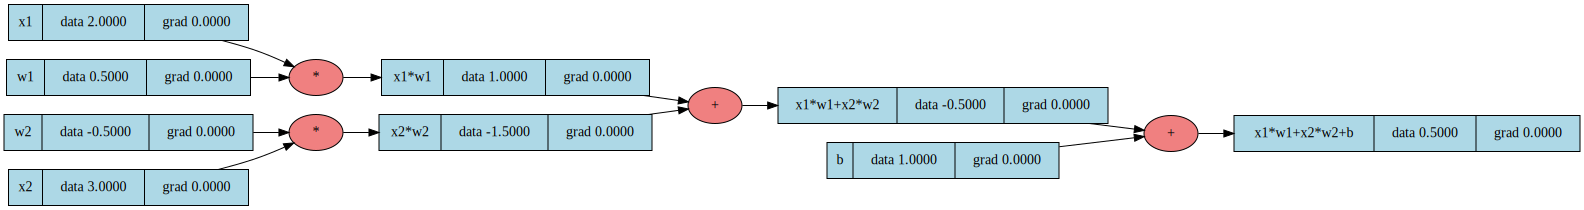

In [18]:
draw_dot(z)

In [20]:

out = z.sigmoid()


In [ ]:

# Manual backpropagation
out.grad = 1.0

s = out.data
z.grad = out.grad * s*(1-s)

b.grad += z.grad
sum_xw.grad = z.grad

x1w1.grad += sum_xw.grad
x2w2.grad += sum_xw.grad

# x1w1 = x1 * w1
x1.grad += x1w1.grad * w1.data
w1.grad += x1w1.grad * x1.data

# x2w2 = x2 * w2
x2.grad += x2w2.grad * w2.data
w2.grad += x2w2.grad * x2.data


In [ ]:

# create scalar tensors in PyTorch
tx1 = torch.tensor(2.0, requires_grad=True)
tx2 = torch.tensor(3.0, requires_grad=True)
tw1 = torch.tensor(0.5, requires_grad=True)
tw2 = torch.tensor(-0.5, requires_grad=True)
tb  = torch.tensor(1.0, requires_grad=True)

tz = tx1 * tw1 + tx2 * tw2 + tb
tout = torch.sigmoid(tz)

print("\nForward intermediates:")
print(tz.item())
print(tout.item())